<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 3. MultiLayer Perceptron</font></h1>

<h1><font color="#113D68" size=4>4. Crear un bucle de entrenamiento</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Elementos del entrenamiento de un modelo de aprendizaje profundo](#section1)
* [2. Recolectando estadísticas durante el entrenamiento](#section2)
* [3. Uso de `tqdm` para reportar el progreso del entrenamiento](#section3)


---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

PyTorch proporciona muchos bloques de construcción para un modelo de aprendizaje profundo, pero un ciclo de entrenamiento no forma parte de ellos. Esto te da la flexibilidad de hacer lo que quieras durante el entrenamiento, pero existe una estructura básica que es común en la mayoría de los casos de uso.

En este capítulo, verás cómo crear un ciclo de entrenamiento que proporcione información esencial para el entrenamiento de tu modelo, con la opción de mostrar cualquier información que desees. Después de completar este capítulo, sabrás:

- Los bloques básicos de un ciclo de entrenamiento
- Cómo usar `tqdm` para mostrar el progreso del entrenamiento

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch tutorials.](https://pytorch.org/tutorials/)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch Documentation](https://pytorch.org/docs/stable/index.html).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`tqdm`](https://github.com/tqdm/tqdm).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch API. [`torch.optim`](https://pytorch.org/docs/stable/optim.html).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch Tutorials. [Optimizing Model Parameters](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Elementos del entrenamiento de un modelo de aprendizaje profundo</font>

- El diseño del modelo especifica el algoritmo para manipular una entrada y producir una salida.

- Los parámetros del modelo (pesos, sesgos, kernels) se ajustan durante el entrenamiento.

- El entrenamiento implica alimentar datos de muestra al modelo para que un optimizador ajuste estos parámetros.

- Se recomienda dividir el conjunto de datos en dos partes: train/test.

    - El conjunto de train se divide en lotes y se usa en el ciclo de entrenamiento.

    - El conjunto de test se utiliza para evaluar el rendimiento del modelo en datos no vistos.

- El ciclo de entrenamiento incluye un pase hacia adelante (entrada a salida) y un pase hacia atrás (cálculo de gradientes).

- Los gradientes se utilizan en el algoritmo de descenso de gradiente para ajustar los parámetros del modelo.

In [1]:
# Descarga de datos (necesario en Colab): se guardan en ./Datasets
import os, urllib.request

os.makedirs('Datasets', exist_ok=True)
urls = {
    'pima-indians-diabetes.csv':
        'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv',
}
for nombre, url in urls.items():
    if not os.path.exists(f'Datasets/{nombre}'):
        urllib.request.urlretrieve(url, f'Datasets/{nombre}')

In [2]:
import numpy as np
import torch

dataset = np.loadtxt('Datasets/pima-indians-diabetes.csv', delimiter=',')
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

Xtrain = X[:int(0.7 * len(X))]  # 70% train
ytrain = y[:int(0.7 * len(y))]
Xtest = X[int(0.7 * len(X)):]  # 30% test
ytest = y[int(0.7 * len(y)):]

Puedes reutilizar el modelo, la función de pérdida y el optimizador de un capítulo anterior:

In [3]:
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


Con los datos y el modelo listos, este es el ciclo de entrenamiento mínimo, con el pase hacia adelante y hacia atrás en cada paso.

En el ciclo interno: 
1. Toma cada lote del conjunto de datos y evalúa la pérdida. 

2. La pérdida es un tensor de PyTorch que recuerda cómo se obtiene su valor. 

3. Luego, reinicia todos los gradientes (`zero_grad()`) que maneja el optimizador

4. Llama a `loss.backward()` para ejecutar el algoritmo de retropropagación.

6. Luego, al llamar a `step()`, el optimizador verificará cada parámetro que gestiona y los actualizará.


In [4]:
n_epochs = 50    
batch_size = 10  
batches_per_epoch = len(Xtrain) // batch_size

for epoch in range(n_epochs):
    for i in range(batches_per_epoch):
        start = i * batch_size
        Xbatch = Xtrain[start:start + batch_size]
        ybatch = ytrain[start:start + batch_size]
        y_pred = model(Xbatch)
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Una vez que todo esté hecho, puedes ejecutar el modelo con el conjunto de test para evaluar su rendimiento. 

In [5]:
with torch.no_grad():
    y_pred = model(Xtest)
accuracy = (y_pred.round() == ytest).float().mean()
print("Accuracy {:.2f}".format(accuracy * 100))

Accuracy 70.56


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Recolectando estadísticas durante el entrenamiento</font>

- El ciclo de entrenamiento básico es adecuado para modelos pequeños con entrenamiento rápido.

- Para modelos más grandes o conjuntos de datos extensos, se necesita monitorear el progreso del entrenamiento.

- Aspectos importantes a observar durante el entrenamiento:

  • Métrica de pérdida en cada paso (se espera que disminuya).

  • Otras métricas, como el accuracy en el conjunto de entrenamiento que vaya aumentado.

  • Evaluación del modelo con el conjunto test al final de cada época.

  • Visualización de todas las métricas al final del entrenamiento.
  
- Se requiere código adicional en el ciclo de entrenamiento para implementar estas funcionalidades.

In [6]:
n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

train_loss = []
train_acc = []
test_acc = []

for epoch in range(n_epochs):
    for i in range(batches_per_epoch):
        start = i * batch_size
        Xbatch = Xtrain[start:start + batch_size]
        ybatch = ytrain[start:start + batch_size]
        y_pred = model(Xbatch)
        loss = loss_fn(y_pred, ybatch)
        acc = (y_pred.round() == ybatch).float().mean()
        train_loss.append(float(loss))
        train_acc.append(float(acc))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"epoch {epoch} step {i} loss {loss} accuracy {acc}")
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"End of {epoch}, accuracy {acc}")

epoch 0 step 0 loss 0.7171246409416199 accuracy 0.5
epoch 0 step 1 loss 0.6768546104431152 accuracy 0.6000000238418579
epoch 0 step 2 loss 0.6782771348953247 accuracy 0.5
epoch 0 step 3 loss 0.76506108045578 accuracy 0.699999988079071
epoch 0 step 4 loss 0.7118474245071411 accuracy 0.4000000059604645
epoch 0 step 5 loss 0.4556868076324463 accuracy 1.0
epoch 0 step 6 loss 0.6916726231575012 accuracy 0.6000000238418579
epoch 0 step 7 loss 0.5422409772872925 accuracy 0.6000000238418579
epoch 0 step 8 loss 0.5305789709091187 accuracy 0.8999999761581421
epoch 0 step 9 loss 0.6322773694992065 accuracy 0.800000011920929
epoch 0 step 10 loss 0.6030078530311584 accuracy 0.800000011920929
epoch 0 step 11 loss 0.6057626605033875 accuracy 0.800000011920929
epoch 0 step 12 loss 0.7923591732978821 accuracy 0.5
epoch 0 step 13 loss 0.4920662045478821 accuracy 0.8999999761581421
epoch 0 step 14 loss 0.466765820980072 accuracy 0.800000011920929
epoch 0 step 15 loss 0.6419278979301453 accuracy 0.8000000

/tmp/ipykernel_438560/2543214240.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  train_loss.append(float(loss))


epoch 6 step 28 loss 0.7633051872253418 accuracy 0.6000000238418579
epoch 6 step 29 loss 0.7009835243225098 accuracy 0.5
epoch 6 step 30 loss 0.6532124280929565 accuracy 0.5
epoch 6 step 31 loss 0.614864706993103 accuracy 0.800000011920929
epoch 6 step 32 loss 0.863386332988739 accuracy 0.20000000298023224
epoch 6 step 33 loss 0.5952973365783691 accuracy 0.800000011920929
epoch 6 step 34 loss 0.6711636185646057 accuracy 0.6000000238418579
epoch 6 step 35 loss 0.5077650547027588 accuracy 0.800000011920929
epoch 6 step 36 loss 0.607546329498291 accuracy 0.6000000238418579
epoch 6 step 37 loss 0.5421141386032104 accuracy 0.699999988079071
epoch 6 step 38 loss 0.7159868478775024 accuracy 0.699999988079071
epoch 6 step 39 loss 0.6749468445777893 accuracy 0.699999988079071
epoch 6 step 40 loss 0.6816763877868652 accuracy 0.6000000238418579
epoch 6 step 41 loss 0.6003178358078003 accuracy 0.699999988079071
epoch 6 step 42 loss 0.5678409337997437 accuracy 0.800000011920929
epoch 6 step 43 loss

epoch 7 step 20 loss 0.535094141960144 accuracy 0.800000011920929
epoch 7 step 21 loss 0.7316201329231262 accuracy 0.5
epoch 7 step 22 loss 0.6475358009338379 accuracy 0.6000000238418579
epoch 7 step 23 loss 0.6371222734451294 accuracy 0.6000000238418579
epoch 7 step 24 loss 0.5615040063858032 accuracy 0.8999999761581421
epoch 7 step 25 loss 0.6277602910995483 accuracy 0.699999988079071
epoch 7 step 26 loss 0.5436877012252808 accuracy 0.800000011920929
epoch 7 step 27 loss 0.5837552547454834 accuracy 0.800000011920929
epoch 7 step 28 loss 0.7633856534957886 accuracy 0.6000000238418579
epoch 7 step 29 loss 0.7003776431083679 accuracy 0.5
epoch 7 step 30 loss 0.652180552482605 accuracy 0.5
epoch 7 step 31 loss 0.6138896942138672 accuracy 0.800000011920929
epoch 7 step 32 loss 0.8634611368179321 accuracy 0.20000000298023224
epoch 7 step 33 loss 0.5944136381149292 accuracy 0.800000011920929
epoch 7 step 34 loss 0.6710484623908997 accuracy 0.6000000238418579
epoch 7 step 35 loss 0.505627930

epoch 13 step 41 loss 0.594111442565918 accuracy 0.699999988079071
epoch 13 step 42 loss 0.569377601146698 accuracy 0.800000011920929
epoch 13 step 43 loss 0.5001465678215027 accuracy 0.8999999761581421
epoch 13 step 44 loss 0.7370696067810059 accuracy 0.5
epoch 13 step 45 loss 0.5156985521316528 accuracy 0.800000011920929
epoch 13 step 46 loss 0.4632217288017273 accuracy 0.800000011920929
epoch 13 step 47 loss 0.49158263206481934 accuracy 0.8999999761581421
epoch 13 step 48 loss 0.5415060520172119 accuracy 0.8999999761581421
epoch 13 step 49 loss 0.5163755416870117 accuracy 0.699999988079071
epoch 13 step 50 loss 0.6188937425613403 accuracy 0.699999988079071
epoch 13 step 51 loss 0.6551555395126343 accuracy 0.6000000238418579
epoch 13 step 52 loss 0.5820795893669128 accuracy 0.800000011920929
End of 13, accuracy 0.7142857313156128
epoch 14 step 0 loss 0.7199693918228149 accuracy 0.5
epoch 14 step 1 loss 0.6648732423782349 accuracy 0.699999988079071
epoch 14 step 2 loss 0.6554418802261

...

epoch 35 step 24 loss 0.5539682507514954 accuracy 0.800000011920929
epoch 35 step 25 loss 0.6248600482940674 accuracy 0.699999988079071
epoch 35 step 26 loss 0.49345946311950684 accuracy 0.800000011920929
epoch 35 step 27 loss 0.545036256313324 accuracy 0.800000011920929
epoch 35 step 28 loss 0.7677306532859802 accuracy 0.5
epoch 35 step 29 loss 0.6858702898025513 accuracy 0.5
epoch 35 step 30 loss 0.6318458914756775 accuracy 0.699999988079071
epoch 35 step 31 loss 0.5981870293617249 accuracy 0.800000011920929
epoch 35 step 32 loss 0.8723093271255493 accuracy 0.30000001192092896
epoch 35 step 33 loss 0.5776360034942627 accuracy 0.8999999761581421
epoch 35 step 34 loss 0.6549212336540222 accuracy 0.699999988079071
epoch 35 step 35 loss 0.46433186531066895 accuracy 0.800000011920929
epoch 35 step 36 loss 0.6148120164871216 accuracy 0.699999988079071
epoch 35 step 37 loss 0.5102832913398743 accuracy 0.800000011920929
epoch 35 step 38 loss 0.6871907711029053 accuracy 0.699999988079071
epoc

epoch 36 step 13 loss 0.45530134439468384 accuracy 1.0
epoch 36 step 14 loss 0.44559207558631897 accuracy 0.800000011920929
epoch 36 step 15 loss 0.5795490741729736 accuracy 0.8999999761581421
epoch 36 step 16 loss 0.5652454495429993 accuracy 0.800000011920929
epoch 36 step 17 loss 0.6820368766784668 accuracy 0.6000000238418579
epoch 36 step 18 loss 0.6166516542434692 accuracy 0.699999988079071
epoch 36 step 19 loss 0.6118091940879822 accuracy 0.699999988079071
epoch 36 step 20 loss 0.5168999433517456 accuracy 0.800000011920929
epoch 36 step 21 loss 0.7264406085014343 accuracy 0.5
epoch 36 step 22 loss 0.6606608629226685 accuracy 0.699999988079071
epoch 36 step 23 loss 0.5914937257766724 accuracy 0.699999988079071
epoch 36 step 24 loss 0.5535270571708679 accuracy 0.8999999761581421
epoch 36 step 25 loss 0.6246897578239441 accuracy 0.699999988079071
epoch 36 step 26 loss 0.4920390248298645 accuracy 0.800000011920929
epoch 36 step 27 loss 0.5438307523727417 accuracy 0.800000011920929
epo

epoch 42 step 43 loss 0.48383650183677673 accuracy 0.800000011920929
epoch 42 step 44 loss 0.6960674524307251 accuracy 0.5
epoch 42 step 45 loss 0.47992557287216187 accuracy 0.800000011920929
epoch 42 step 46 loss 0.4331626892089844 accuracy 0.8999999761581421
epoch 42 step 47 loss 0.4883529245853424 accuracy 0.8999999761581421
epoch 42 step 48 loss 0.5143572092056274 accuracy 0.8999999761581421
epoch 42 step 49 loss 0.5173044800758362 accuracy 0.699999988079071
epoch 42 step 50 loss 0.5881109237670898 accuracy 0.800000011920929
epoch 42 step 51 loss 0.6336188316345215 accuracy 0.6000000238418579
epoch 42 step 52 loss 0.5671097636222839 accuracy 0.800000011920929
End of 42, accuracy 0.7229437232017517
epoch 43 step 0 loss 0.7364899516105652 accuracy 0.5
epoch 43 step 1 loss 0.652469277381897 accuracy 0.6000000238418579
epoch 43 step 2 loss 0.620151162147522 accuracy 0.6000000238418579
epoch 43 step 3 loss 0.7509955167770386 accuracy 0.6000000238418579
epoch 43 step 4 loss 0.72744864225

epoch 43 step 30 loss 0.6266849040985107 accuracy 0.699999988079071
epoch 43 step 31 loss 0.5957371592521667 accuracy 0.800000011920929
epoch 43 step 32 loss 0.8752765655517578 accuracy 0.30000001192092896
epoch 43 step 33 loss 0.5749579071998596 accuracy 0.8999999761581421
epoch 43 step 34 loss 0.6504884362220764 accuracy 0.699999988079071
epoch 43 step 35 loss 0.45628055930137634 accuracy 0.800000011920929
epoch 43 step 36 loss 0.6168555617332458 accuracy 0.699999988079071
epoch 43 step 37 loss 0.5039511322975159 accuracy 0.800000011920929
epoch 43 step 38 loss 0.6795024275779724 accuracy 0.699999988079071
epoch 43 step 39 loss 0.5966012477874756 accuracy 0.699999988079071
epoch 43 step 40 loss 0.676648736000061 accuracy 0.699999988079071
epoch 43 step 41 loss 0.5726965665817261 accuracy 0.699999988079071
epoch 43 step 42 loss 0.5682399272918701 accuracy 0.800000011920929
epoch 43 step 43 loss 0.4834490418434143 accuracy 0.800000011920929
epoch 43 step 44 loss 0.6950669288635254 accu

epoch 49 step 40 loss 0.6783304810523987 accuracy 0.699999988079071
epoch 49 step 41 loss 0.5698856711387634 accuracy 0.699999988079071
epoch 49 step 42 loss 0.5670149326324463 accuracy 0.800000011920929
epoch 49 step 43 loss 0.48105549812316895 accuracy 0.800000011920929
epoch 49 step 44 loss 0.6899530291557312 accuracy 0.5
epoch 49 step 45 loss 0.473161518573761 accuracy 0.800000011920929
epoch 49 step 46 loss 0.4289589524269104 accuracy 0.8999999761581421
epoch 49 step 47 loss 0.4871305525302887 accuracy 0.8999999761581421
epoch 49 step 48 loss 0.508584201335907 accuracy 0.8999999761581421
epoch 49 step 49 loss 0.5183989405632019 accuracy 0.699999988079071
epoch 49 step 50 loss 0.5814770460128784 accuracy 0.800000011920929
epoch 49 step 51 loss 0.6270886063575745 accuracy 0.6000000238418579
epoch 49 step 52 loss 0.5635011792182922 accuracy 0.800000011920929
End of 49, accuracy 0.7229437232017517


- Se recolectan la pérdida y la precisión en listas durante el entrenamiento.

- Es posible graficar estas métricas utilizando `matplotlib`.

- Se debe tener en cuenta que las estadísticas del conjunto de entrenamiento se recolectan en cada paso.

- El accuracy del conjunto de test solo se evalúa al final de cada época.

- Para una comparación adecuada, se recomienda mostrar el accuracy promedio del ciclo de entrenamiento por época.

- La primera gráficaf muestra la pérdida durante el entrenamiento.

- La segunda gráfica presenta el accuracy promedio por época en el conjunto de test.

- Se observa una disminución en la pérdida de entrenamiento a medida que avanzan los pasos.

- El accuracy en test muestra una tendencia ascendente a lo largo de las épocas, indicando una mejora en el rendimiento del modelo.

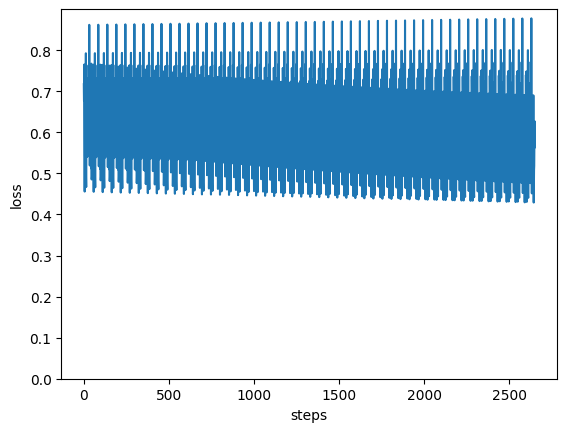

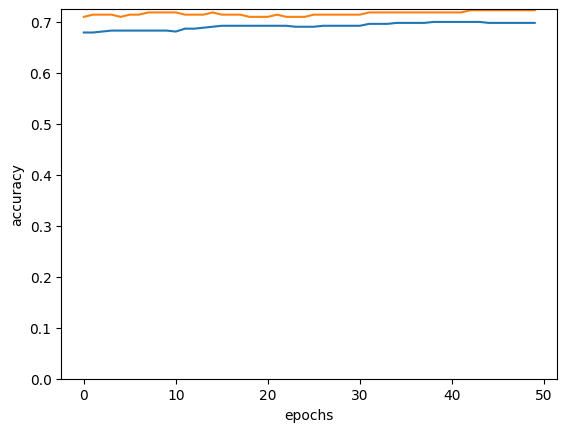

In [7]:
import matplotlib.pyplot as plt

plt.plot(train_loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.ylim(0)
plt.show()

avg_train_acc = []
for i in range(n_epochs):
    start = i * batch_size
    average = sum(train_acc[start:start+batches_per_epoch]) / batches_per_epoch
    avg_train_acc.append(average)

plt.plot(avg_train_acc, label="train")
plt.plot(test_acc, label="test")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Uso de `tqdm` para reportar el progreso del entrenamiento</font>

Ahora veamos el primer código:
- La ejecución del código anterior genera numerosas líneas de salida durante el entrenamiento.

- Se puede implementar una barra de progreso animada para visualizar el avance del entrenamiento.

- La biblioteca `tqdm` es una herramienta popular para crear barras de progreso.

- La conversión del código para usar `tqdm` es sencilla.

#### Características:
- Utiliza `tqdm.trange()` para crear la barra de progreso, que es similar a `range()`.

- Dentro del bucle `for`, la variable `i` actúa como el índice del lote (batch), y luego se calcula `start = i * batch_size` en cada iteración para determinar el índice inicial de cada lote.

- Cada lote es seleccionado dentro del bucle utilizando este índice calculado (`start`).

#### Resumen:
Este código calcula los índices `start` dinámicamente dentro del bucle principal para cada lote basado en el número de `batches_per_epoch`.

In [8]:
import tqdm

n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

# collect statistics
train_loss = []
train_acc = []
test_acc = []

for epoch in range(n_epochs):
    with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            # tomar un lote (batch)
            start = i * batch_size
            Xbatch = Xtrain[start:start + batch_size]
            ybatch = ytrain[start:start + batch_size]
            
            # paso hacia adelante (forward pass)
            y_pred = model(Xbatch)
            loss = loss_fn(y_pred, ybatch)
            acc = (y_pred.round() == ybatch).float().mean()
            
            # almacenar las métricas
            train_loss.append(float(loss))
            train_acc.append(float(acc))
            
            # paso hacia atrás (backward pass)
            optimizer.zero_grad()
            loss.backward()
            
            # actualizar los pesos
            optimizer.step()
            
            # mostrar el progreso
            bar.set_postfix(
                loss=float(loss),
                acc=f"{float(acc) * 100:.2f}%"
            )
    
    # evaluar el modelo al final de la época
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"Fin de la época {epoch}, Accuracy {acc}")

  0%|          | 0/53 [00:00<?, ?batch/s]

Epoch 0:   0%|          | 0/53 [00:00<?, ?batch/s]

Epoch 0:   0%|          | 0/53 [00:00<?, ?batch/s, acc=50.00%, loss=0.74]

Epoch 0:   2%|▏         | 1/53 [00:00<00:00, 571.51batch/s, acc=50.00%, loss=0.74]

Epoch 0:   2%|▏         | 1/53 [00:00<00:00, 571.51batch/s, acc=60.00%, loss=0.651]

...

Epoch 49:  98%|█████████▊| 52/53 [00:00<00:00, 764.09batch/s, acc=80.00%, loss=0.601]

Epoch 49:  98%|█████████▊| 52/53 [00:00<00:00, 764.09batch/s, acc=80.00%, loss=0.543]

Epoch 49: 100%|██████████| 53/53 [00:00<00:00, 770.84batch/s, acc=80.00%, loss=0.543]

Epoch 49: 100%|██████████| 53/53 [00:00<00:00, 661.63batch/s, acc=80.00%, loss=0.543]

Fin de la época 49, Accuracy 0.7359307408332825


Ahora veamos el siguiente código:
- `tqdm` crea un iterador con `trange()`, similar a la función `range()` de Python.

- Se puede iterar sobre este iterador dentro del ciclo de entrenamiento.

- La barra de progreso se puede actualizar modificando su descripción o los datos de "postfix".

- Las actualizaciones deben realizarse antes de que termine el ciclo.

- La función `set_postfix()` permite mostrar cualquier información deseada en la barra de progreso.

- Además de `trange()`, existe la función `tqdm()` que itera sobre una lista existente.

- `tqdm()` puede ser más fácil de usar en algunos casos.

#### Características:

- Antes del bucle principal, crea una lista `starts` que contiene todos los índices iniciales (`start = i * batch_size`) de los lotes (batches) para cada época.

- Luego, usa `tqdm.tqdm()` para iterar directamente sobre esa lista `starts`.

- No necesita calcular `start` dentro del bucle, ya que los valores ya están precomputados y almacenados en la lista `starts`.


#### Resumen:

Este código precomputa los índices iniciales (`start`) para todos los lotes antes de comenzar el bucle de épocas. Luego, itera directamente sobre esos valores en lugar de calcularlos dinámicamente en cada iteración.

In [9]:
import tqdm

# generar los puntos de inicio para cada batch
starts = [i * batch_size for i in range(batches_per_epoch)]

for epoch in range(n_epochs):
    # usar tqdm para la barra de progreso
    with tqdm.tqdm(starts, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # tomar un lote (batch)
            Xbatch = Xtrain[start:start + batch_size]
            ybatch = ytrain[start:start + batch_size]
            
            # paso hacia adelante (forward pass)
            y_pred = model(Xbatch)
            loss = loss_fn(y_pred, ybatch)
            acc = (y_pred.round() == ybatch).float().mean()
            
            # almacenar las métricas
            train_loss.append(float(loss))
            train_acc.append(float(acc))
            
            # paso hacia atrás (backward pass)
            optimizer.zero_grad()
            loss.backward()
            
            # actualizar los pesos
            optimizer.step()
            
            # actualizar la barra de progreso
            bar.set_postfix(
                loss=float(loss),
                acc=f"{float(acc) * 100:.2f}%"
            )
    
    # evaluar el modelo al final de la época
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"Fin de la época {epoch}, Accuracy {acc}")

  0%|          | 0/53 [00:00<?, ?batch/s]

Epoch 0:   0%|          | 0/53 [00:00<?, ?batch/s]

Epoch 0:   0%|          | 0/53 [00:00<?, ?batch/s, acc=60.00%, loss=0.774]

Epoch 0:   2%|▏         | 1/53 [00:00<00:00, 440.95batch/s, acc=60.00%, loss=0.774]

Epoch 0:   2%|▏         | 1/53 [00:00<00:00, 440.95batch/s, acc=60.00%, loss=0.642]

...

Epoch 49:  98%|█████████▊| 52/53 [00:00<00:00, 754.22batch/s, acc=80.00%, loss=0.593]

Epoch 49:  98%|█████████▊| 52/53 [00:00<00:00, 754.22batch/s, acc=70.00%, loss=0.529]

Epoch 49: 100%|██████████| 53/53 [00:00<00:00, 761.74batch/s, acc=70.00%, loss=0.529]

Epoch 49: 100%|██████████| 53/53 [00:00<00:00, 767.41batch/s, acc=70.00%, loss=0.529]

Fin de la época 49, Accuracy 0.7316017150878906


### Diferencias Clave entre el primer y segundo código:

1. **Cálculo del índice `start`**:

   - En el primer código, el índice `start` se calcula dinámicamente dentro del bucle usando el índice `i`.

   - En el segundo código, los índices `start` se calculan antes de que comience el bucle y se almacenan en la lista `starts`, eliminando la necesidad de calcularlos dentro del bucle.

2. **Uso de `tqdm`**:

   - El primer código usa `tqdm.trange()`, que es una versión de `range()` con una barra de progreso.

   - El segundo código usa `tqdm.tqdm()` para iterar directamente sobre la lista de inicios precomputados (`starts`).

Ambos códigos funcionan de manera similar, pero el segundo es más eficiente si los índices iniciales de los lotes son constantes o si prefieres precomputar estos valores para mayor claridad.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>